Running Susceptibility (Variance) Sweep...


100%|██████████| 15/15 [01:11<00:00,  4.78s/it]


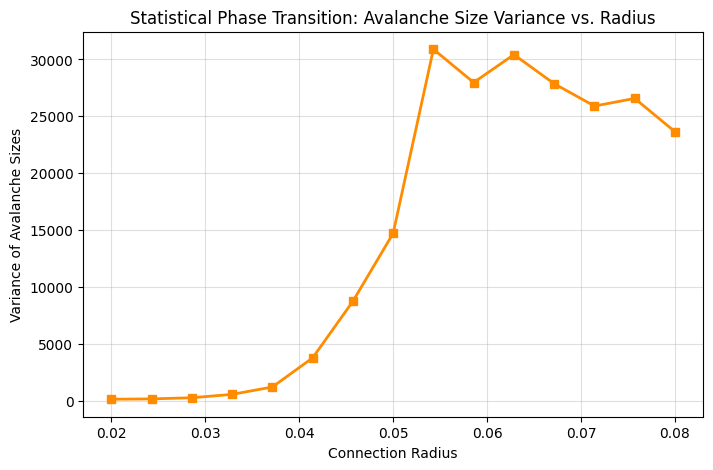

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

def get_avalanche_variance(radius):
    NUM_NODES, TOL, NOISE, STEPS = 1000, 0.20, 0.8, 3000
    G = nx.random_geometric_graph(NUM_NODES, radius=radius)

    for node in G.nodes():
        load = np.random.uniform(0, 10)
        G.nodes[node]['load'] = load
        G.nodes[node]['capacity'] = load * (1 + TOL)
        G.nodes[node]['tripped'] = False

    avalanches = []

    for step in range(STEPS):
        for node in G.nodes(): G.nodes[node]['load'] += (NOISE / 10.0)
        current_avalanche = 0

        while True:
            overloaded = [n for n, d in G.nodes(data=True) if d['load'] > d['capacity'] and not d['tripped']]
            if not overloaded: break

            for node in overloaded:
                overload_amt = G.nodes[node]['load']
                G.nodes[node]['load'] = 0
                G.nodes[node]['tripped'] = True
                current_avalanche += 1

                active_nbrs = [nbr for nbr in G.neighbors(node) if not G.nodes[nbr]['tripped']]
                if active_nbrs:
                    spill = overload_amt / len(active_nbrs)
                    for nbr in active_nbrs: G.nodes[nbr]['load'] += spill

        if current_avalanche > 0:
            avalanches.append(current_avalanche)

        for node in G.nodes(): G.nodes[node]['tripped'] = False

    # Return 0 if no avalanches happened, else return the variance
    return np.var(avalanches) if avalanches else 0

# --- THE VARIANCE SWEEP ---
# Zooming in closely on the critical zone
radii = np.linspace(0.02, 0.08, 15)
variances = []

print("Running Susceptibility (Variance) Sweep...")
for r in tqdm(radii):
    variances.append(get_avalanche_variance(r))

# --- PLOTTING ---
plt.figure(figsize=(8, 5))
plt.plot(radii, variances, marker='s', color='darkorange', linewidth=2)
plt.title("Statistical Phase Transition: Avalanche Size Variance vs. Radius")
plt.xlabel("Connection Radius")
plt.ylabel("Variance of Avalanche Sizes")
plt.grid(True, alpha=0.4)
plt.show()